# Ngày 5 (mở rộng, phần 3) — Survival Analysis: KHI NÀO người ta nghỉ việc

Toàn bộ phân tích trước (SHAP, cost-benefit, persona) trả lời **AI** có nguy cơ cao. Notebook
này hỏi một câu khác hẳn: **THỜI ĐIỂM nào trong vòng đời một nhân viên là rủi ro nhất?**
Đây là một kỹ thuật thống kê khác hoàn toàn — Survival Analysis (phân tích sống còn, vốn dùng
trong y khoa để đo thời gian đến 1 sự kiện) — áp dụng vào HR: "thời gian đến khi nghỉ việc".

> **Giới hạn cần biết trước:** dữ liệu là 1 lát cắt tại 1 thời điểm (cross-sectional), không
> phải theo dõi dọc theo thời gian thật. Người chưa nghỉ được xem là "censored" tại đúng số
> năm hiện tại của họ — cách làm chuẩn trong survival analysis, nhưng không thay thế được dữ
> liệu theo dõi thật nếu có.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

raw = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
T = raw['YearsAtCompany']          # thời gian quan sát (năm)
E = (raw['Attrition']=='Yes').astype(int)   # 1 = đã nghỉ (event), 0 = vẫn đang làm (censored)


## 1. Đường cong Kaplan-Meier — toàn công ty

Đường cong trả lời: "trong số nhân viên còn ở lại đến năm X, bao nhiêu % sẽ *còn* ở lại đến
năm sau"?

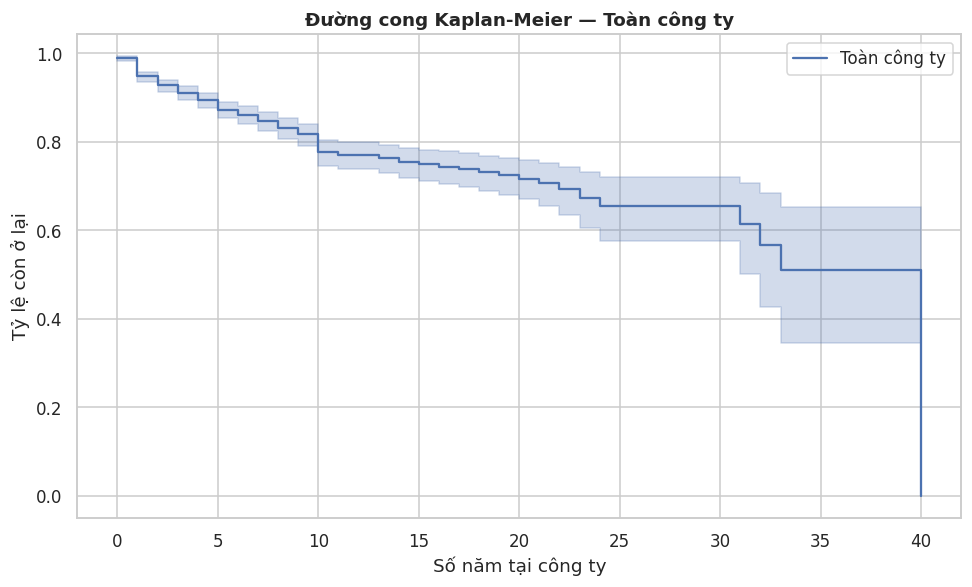

Sau 1 năm, còn lại: 94.8%
Sau 2 năm, còn lại: 92.8%
Sau 3 năm, còn lại: 91.1%
Sau 5 năm, còn lại: 87.3%
Sau 10 năm, còn lại: 77.7%


In [2]:
kmf = KaplanMeierFitter()
kmf.fit(T, E, label="Toàn công ty")

plt.figure(figsize=(9, 5.5))
kmf.plot_survival_function()
plt.xlabel("Số năm tại công ty")
plt.ylabel("Tỷ lệ còn ở lại")
plt.title("Đường cong Kaplan-Meier — Toàn công ty")
plt.tight_layout()
plt.savefig("../images/21_kaplan_meier_overall.png", bbox_inches='tight')
plt.show()

for yr in [1, 2, 3, 5, 10]:
    print(f"Sau {yr} năm, còn lại: {kmf.survival_function_at_times(yr).values[0]*100:.1f}%")


## 2. Phát hiện: "Vách đá năm 1"

Nhìn thoáng qua đường cong có vẻ giảm đều — nhưng nhìn vào *phân phối tenure của riêng những
người đã nghỉ* thì lộ ra một điều đường cong tổng không thể hiện rõ.

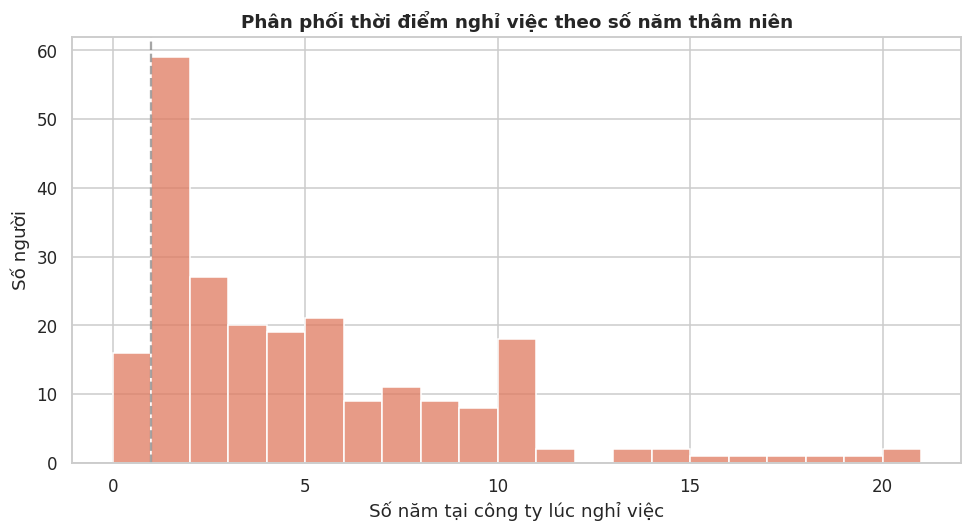

31.6% tổng số người nghỉ việc rời đi trong VÒNG 1 NĂM đầu tiên
43.0% rời đi trong vòng 2 năm đầu


In [3]:
leavers_tenure = raw[raw['Attrition']=='Yes']['YearsAtCompany']

plt.figure(figsize=(9, 5))
sns.histplot(leavers_tenure, bins=range(0, 22), color='#e07a5f')
plt.axvline(1, color='gray', linestyle='--', alpha=0.7)
plt.xlabel("Số năm tại công ty lúc nghỉ việc")
plt.ylabel("Số người")
plt.title("Phân phối thời điểm nghỉ việc theo số năm thâm niên")
plt.tight_layout()
plt.savefig("../images/22_tenure_cliff.png", bbox_inches='tight')
plt.show()

pct_1y = (leavers_tenure <= 1).mean() * 100
pct_2y = (leavers_tenure <= 2).mean() * 100
print(f"{pct_1y:.1f}% tổng số người nghỉ việc rời đi trong VÒNG 1 NĂM đầu tiên")
print(f"{pct_2y:.1f}% rời đi trong vòng 2 năm đầu")


**31.6% của TẤT CẢ người từng nghỉ việc rời đi ngay trong năm đầu tiên** — gần 1/3. Đây
là phát hiện có thể hành động ngay: onboarding và 12 tháng đầu là giai đoạn rủi ro cao nhất
theo đúng nghĩa đen, không phải cảm tính. Chính sách giữ chân nên tập trung nguồn lực vào
mốc "check-in tháng thứ 6, 9, 12" thay vì rải đều cho mọi thâm niên.

## 3. OverTime ảnh hưởng thế nào đến TỐC ĐỘ rời đi (không chỉ có/không)?

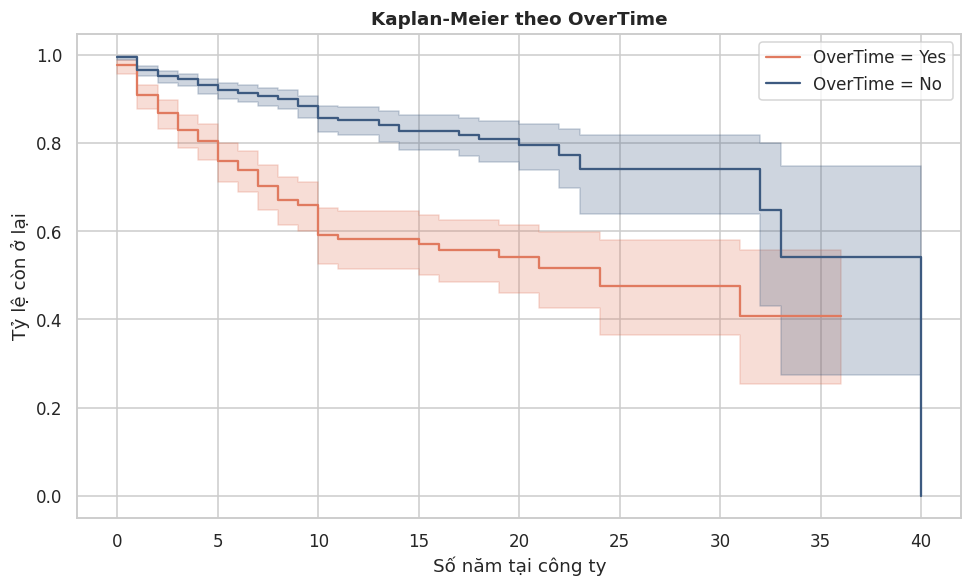

Log-rank test p-value: 1.58e-19 (khác biệt cực kỳ có ý nghĩa thống kê)

Median thời gian 'sống' — OT=Yes: 24 năm | OT=No: 40 năm
Năm 1: OT=Yes còn 90.8% | OT=No còn 96.4%
Năm 3: OT=Yes còn 83.0% | OT=No còn 94.4%
Năm 5: OT=Yes còn 75.9% | OT=No còn 92.0%


In [4]:
ot_yes = raw['OverTime'] == 'Yes'
kmf_yes = KaplanMeierFitter().fit(T[ot_yes], E[ot_yes], label='OverTime = Yes')
kmf_no = KaplanMeierFitter().fit(T[~ot_yes], E[~ot_yes], label='OverTime = No')

plt.figure(figsize=(9, 5.5))
kmf_yes.plot_survival_function(color='#e07a5f')
kmf_no.plot_survival_function(color='#3d5a80')
plt.xlabel("Số năm tại công ty")
plt.ylabel("Tỷ lệ còn ở lại")
plt.title("Kaplan-Meier theo OverTime")
plt.tight_layout()
plt.savefig("../images/23_kaplan_meier_overtime.png", bbox_inches='tight')
plt.show()

result = logrank_test(T[ot_yes], T[~ot_yes], E[ot_yes], E[~ot_yes])
print(f"Log-rank test p-value: {result.p_value:.2e} (khác biệt cực kỳ có ý nghĩa thống kê)")
print(f"\nMedian thời gian 'sống' — OT=Yes: {kmf_yes.median_survival_time_:.0f} năm | OT=No: {kmf_no.median_survival_time_:.0f} năm")
for yr in [1, 3, 5]:
    print(f"Năm {yr}: OT=Yes còn {kmf_yes.survival_function_at_times(yr).values[0]*100:.1f}% "
          f"| OT=No còn {kmf_no.survival_function_at_times(yr).values[0]*100:.1f}%")


## 4. Cox Proportional Hazards — định lượng bằng "tốc độ gấp mấy lần"

SHAP (Ngày 4) cho biết mức đóng góp vào 1 dự đoán cụ thể. Cox model cho một con số khác, dễ
nói chuyện với sếp hơn: **"người có đặc điểm X rời đi nhanh gấp bao nhiêu lần"**, kiểm soát
đồng thời tất cả biến khác.

In [5]:
cox_df = raw[['YearsAtCompany','Attrition','OverTime','MonthlyIncome','Age','StockOptionLevel',
              'DistanceFromHome','JobSatisfaction','NumCompaniesWorked']].copy()
cox_df['Attrition'] = (cox_df['Attrition']=='Yes').astype(int)
cox_df['OverTime'] = (cox_df['OverTime']=='Yes').astype(int)
cox_df['MonthlyIncome'] = cox_df['MonthlyIncome'] / 1000       # đổi sang nghìn $ cho dễ đọc
cox_df['YearsAtCompany'] = cox_df['YearsAtCompany'].replace(0, 0.5)   # Cox cần T > 0

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='YearsAtCompany', event_col='Attrition')
hr = cph.summary[['exp(coef)', 'p']].sort_values('exp(coef)', ascending=False)
hr.columns = ['Hazard Ratio', 'p-value']
print(f"Concordance index (giống AUC cho survival model): {cph.concordance_index_:.3f}\n")
hr.round(4)


Concordance index (giống AUC cho survival model): 0.837



,Hazard Ratio,p-value
covariate,,
OverTime,3.3716,0.0000
NumCompaniesWorked,1.1903,0.0000
DistanceFromHome,1.0279,0.0004
Age,0.9302,0.0000
MonthlyIncome,0.8120,0.0000
JobSatisfaction,0.7979,0.0001
StockOptionLevel,0.6424,0.0000


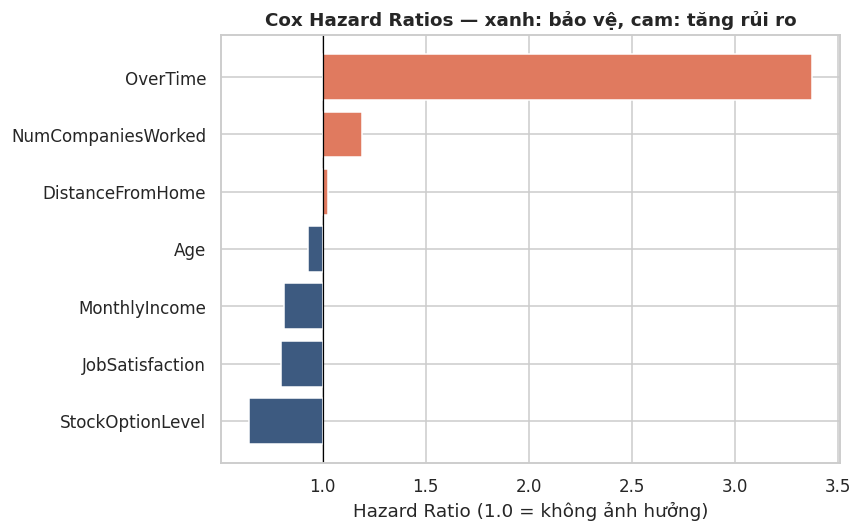

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
hr_sorted = hr.sort_values('Hazard Ratio')
colors = ['#3d5a80' if v < 1 else '#e07a5f' for v in hr_sorted['Hazard Ratio']]
ax.barh(hr_sorted.index, hr_sorted['Hazard Ratio'] - 1, left=1, color=colors)
ax.axvline(1, color='black', linewidth=0.8)
ax.set_xlabel("Hazard Ratio (1.0 = không ảnh hưởng)")
ax.set_title("Cox Hazard Ratios — xanh: bảo vệ, cam: tăng rủi ro")
plt.tight_layout()
plt.savefig("../images/24_cox_hazard_ratios.png", bbox_inches='tight')
plt.show()


**Đọc thành câu nói được ngay với stakeholder (kiểm soát đồng thời mọi biến khác):**
- Nhân viên làm thêm giờ rời đi nhanh gấp **3.37 lần** người không làm thêm giờ
- Mỗi công ty từng làm thêm trong lý lịch tăng tốc độ rời đi thêm **19%**
- Mỗi mức StockOptionLevel tăng thêm giảm tốc độ rời đi **36%**
- Mỗi $1,000 lương tháng tăng thêm giảm tốc độ rời đi **19%**
- Mỗi điểm JobSatisfaction (thang 1-4) tăng thêm giảm tốc độ rời đi **20%**

C-index = 0.837 — mô hình sống còn này phân biệt "ai rời sớm hơn ai" khá tốt, dù mục tiêu
khác hẳn mô hình phân loại chính (dự đoán CÓ/KHÔNG chứ không phải thời điểm).

## Tổng kết

- Phát hiện mới không nằm trong SHAP: **31.6% người nghỉ việc rời đi trong năm đầu tiên** —
  gợi ý retention nên tập trung vào 12 tháng đầu, không dàn trải
- OverTime không chỉ tăng *khả năng* nghỉ việc (SHAP) mà còn tăng *tốc độ* nghỉ việc gấp 3.37
  lần (Cox) — hai kỹ thuật khác nhau, cùng chỉ về một biến, theo hai cách diễn giải bổ trợ nhau
- Cox hazard ratio là cách nói chuyện với người không rành ML dễ hơn nhiều so với SHAP value
  hay xác suất — "gấp 3.37 lần" dễ nhớ, dễ đưa vào slide hơn "SHAP = 0.95"
